In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('done')

done


In [2]:
df = pd.read_csv('swiggy.csv')
print('done')

done


In [5]:
# Set options to display all columns and wide formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Now display the head again
df.head()

,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8680 entries, 0 to 8679
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             8680 non-null   int64  
 1   Area           8680 non-null   object 
 2   City           8680 non-null   object 
 3   Restaurant     8680 non-null   object 
 4   Price          8680 non-null   float64
 5   Avg ratings    8680 non-null   float64
 6   Total ratings  8680 non-null   int64  
 7   Food type      8680 non-null   object 
 8   Address        8680 non-null   object 
 9   Delivery time  8680 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 678.3+ KB


In [8]:
df.head()


,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63


In [9]:
df.describe()

,ID,Price,Avg ratings,Total ratings,Delivery time
count,8680.000000,8680.000000,8680.000000,8680.000000,8680.000000
mean,244812.071429,348.444470,3.655104,156.634793,53.967051
std,158671.617188,230.940074,0.647629,391.448014,14.292335
min,211.000000,0.000000,2.000000,20.000000,20.000000
25%,72664.000000,200.000000,2.900000,50.000000,44.000000
50%,283442.000000,300.000000,3.900000,80.000000,53.000000
75%,393425.250000,400.000000,4.200000,100.000000,64.000000
max,466928.000000,2500.000000,5.000000,10000.000000,109.000000


In [10]:
print(df.isnull().sum())
print(df.info())

ID               0
Area             0
City             0
Restaurant       0
Price            0
Avg ratings      0
Total ratings    0
Food type        0
Address          0
Delivery time    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8680 entries, 0 to 8679
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             8680 non-null   int64  
 1   Area           8680 non-null   object 
 2   City           8680 non-null   object 
 3   Restaurant     8680 non-null   object 
 4   Price          8680 non-null   float64
 5   Avg ratings    8680 non-null   float64
 6   Total ratings  8680 non-null   int64  
 7   Food type      8680 non-null   object 
 8   Address        8680 non-null   object 
 9   Delivery time  8680 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 678.3+ KB
None


In [11]:
df['City'].value_counts().head(10)

City
Kolkata      1346
Mumbai       1277
Chennai      1106
Pune         1090
Hyderabad    1075
Bangalore     946
Ahmedabad     717
Delhi         611
Surat         512
Name: count, dtype: int64

In [12]:
df.groupby('City')['Price'].mean().sort_values(ascending=False)

City
Mumbai       393.794832
Bangalore    382.524313
Kolkata      362.294205
Chennai      356.247740
Pune         353.763303
Delhi        333.301146
Ahmedabad    318.128312
Hyderabad    299.926512
Surat        270.171875
Name: Price, dtype: float64

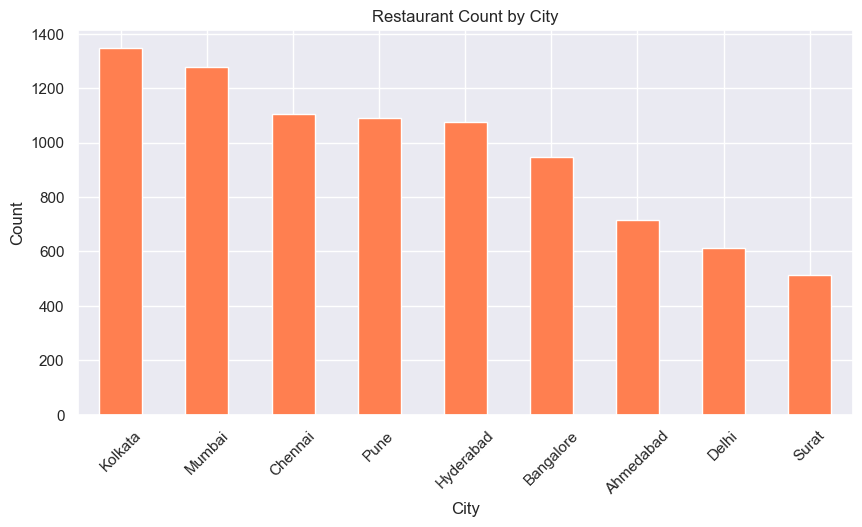

In [17]:


# Set style for nice plots
sns.set_theme(style="darkgrid")

# Top 10 Cities with most restaurants
plt.figure(figsize=(10, 5))
df['City'].value_counts().plot(kind='bar', color='coral')
plt.title('Restaurant Count by City')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Top 10 Most Common Cuisines:
Food type
Chinese         2588
North Indian    1921
Indian          1772
Fast Food       1550
Beverages       1524
Desserts        1436
Biryani         1079
Snacks          1013
South Indian     857
Continental      686
Name: count, dtype: int64


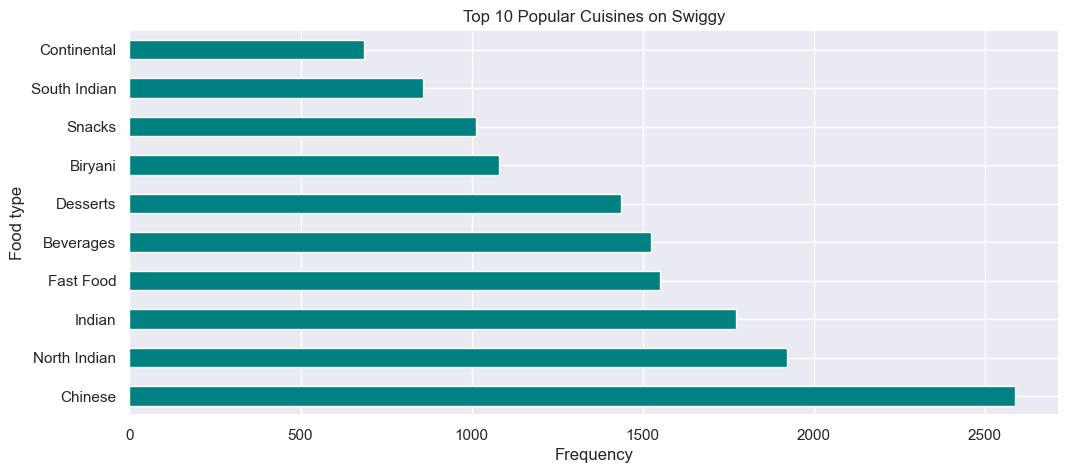

In [18]:
# Split and count all individual cuisines
all_cuisines = df['Food type'].str.split(',').explode().str.strip()
print("Top 10 Most Common Cuisines:")
print(all_cuisines.value_counts().head(10))

# Plot top cuisines
plt.figure(figsize=(12, 5))
all_cuisines.value_counts().head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Popular Cuisines on Swiggy')
plt.xlabel('Frequency')
plt.show()

In [19]:
avg_delivery = df.groupby('City')['Delivery time'].mean().sort_values(ascending=False)
print("Average Delivery Time by City (Minutes):")
print(avg_delivery)

Average Delivery Time by City (Minutes):
City
Kolkata      67.809807
Chennai      58.968354
Pune         55.854128
Delhi        50.734861
Bangalore    50.529598
Hyderabad    49.933023
Surat        48.484375
Mumbai       48.318716
Ahmedabad    44.709902
Name: Delivery time, dtype: float64


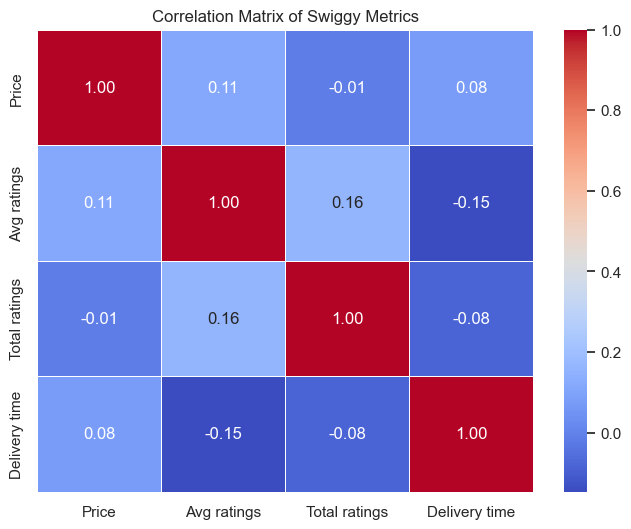

In [20]:
plt.figure(figsize=(8, 6))
numeric_df = df[['Price', 'Avg ratings', 'Total ratings', 'Delivery time']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Swiggy Metrics')
plt.show()

In [22]:
# Create price categories
bins = [0, 200, 500, 1000, 5000]
labels = ['Budget (<200)', 'Mid-Range (200-500)', 'Premium (500-1000)', 'Luxury (1000+)']
df['Price_Tier'] = pd.cut(df['Price'], bins=bins, labels=labels)

# Group by tier to analyze ratings and delivery
tier_analysis = df.groupby('Price_Tier', observed=False).agg(
    Restaurant_Count=('ID', 'count'),
    Avg_Rating=('Avg ratings', 'mean'),
    Avg_Delivery_Time=('Delivery time', 'mean')
).reset_index()

print(tier_analysis)

            Price_Tier  Restaurant_Count  Avg_Rating  Avg_Delivery_Time
0        Budget (<200)              2751    3.604289          53.214467
1  Mid-Range (200-500)              4909    3.642351          53.948462
2   Premium (500-1000)               828    3.842995          55.237923
3       Luxury (1000+)               187    3.910160          60.053476


In [23]:
# Filter for top-tier ratings with high review counts
top_performers = df[(df['Avg ratings'] >= 4.5) & (df['Total ratings'] >= 500)]
print(f"Number of elite restaurants (Rating >= 4.5 & Reviews >= 500): {len(top_performers)}")

# Show top 5 elite restaurants
print(top_performers[['Restaurant', 'City', 'Avg ratings', 'Total ratings', 'Price']].head(5))

Number of elite restaurants (Rating >= 4.5 & Reviews >= 500): 99
                    Restaurant       City  Avg ratings  Total ratings   Price
6    Chinita Real Mexican Food  Bangalore          4.5            500  1000.0
75                    Truffles  Bangalore          4.5           1000   450.0
122                  Theobroma     Mumbai          4.7            500   800.0
125     Corner House Ice Cream  Bangalore          4.7           1000   250.0
129                 Le Plaisir       Pune          4.5            500  1000.0


In [24]:
# Top 10 most expensive areas across all cities
expensive_areas = df.groupby(['City', 'Area'])['Price'].mean().reset_index()
expensive_areas = expensive_areas.sort_values(by='Price', ascending=False)

print("Top 10 Most Expensive Areas for Dining:")
print(expensive_areas.head(10))

Top 10 Most Expensive Areas for Dining:
          City                         Area        Price
672     Mumbai                   Vile Parle  1500.000000
148  Bangalore                Someshwarpura  1200.000000
257      Delhi   Pacific Mall Subhash Nagar  1200.000000
91   Bangalore                 Brigade Road  1100.000000
243      Delhi  Central Market Punjabi Bagh  1050.000000
636     Mumbai               Kurla - Mumbai  1000.000000
127  Bangalore            Mantri Sqare Mall   900.000000
244      Delhi   Central Markt Punjabi Bagh   875.000000
609     Mumbai                  Bandra Area   841.935484
191    Chennai                  Kotturpuram   800.000000


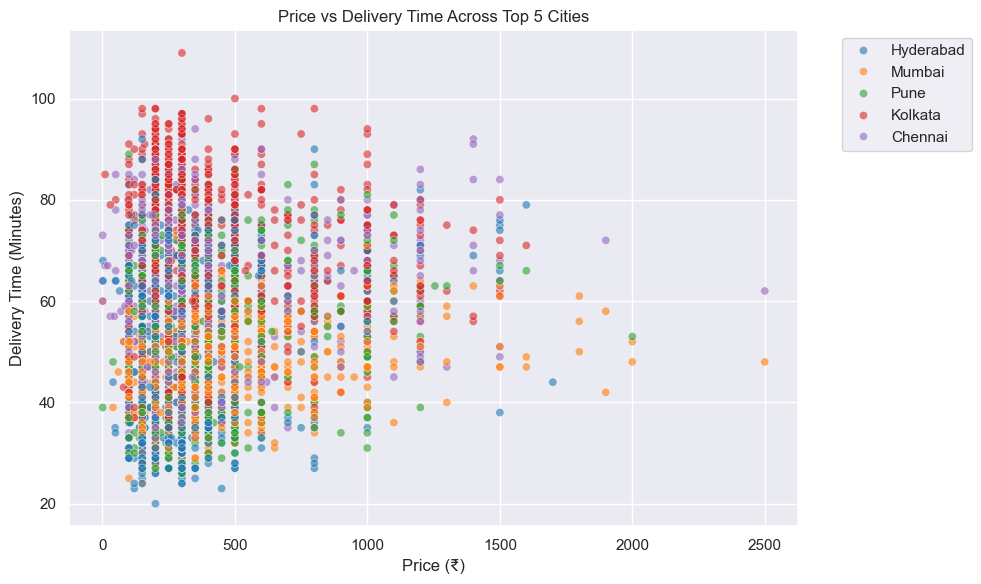

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
top_cities = df['City'].value_counts().head(5).index
subset_df = df[df['City'].isin(top_cities)]

sns.scatterplot(
    data=subset_df, 
    x='Price', 
    y='Delivery time', 
    hue='City', 
    alpha=0.6, 
    palette='tab10'
)
plt.title('Price vs Delivery Time Across Top 5 Cities')
plt.xlabel('Price (₹)')
plt.ylabel('Delivery Time (Minutes)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

# 1. Load your dataframe again
df = pd.read_csv('swiggy.csv')

# 2. Export it to CSV
df.to_csv('cleaned_swiggy_data.csv', index=False)
print("File exported successfully!")

File exported successfully!


In [3]:
import os
print(os.getcwd())

C:\Users\Tarun Das
